# Project Objective

## Objective

The objective of this project is to apply **Hierarchical Clustering** to segment customers into groups based on their purchasing behavior.

Hierarchical Clustering is an unsupervised machine learning algorithm that groups customers according to their similarity without requiring predefined class labels. Unlike K-Means, it also provides a **dendrogram**, which helps visualize how clusters are formed and assists in selecting an appropriate number of clusters.

By analyzing customer characteristics such as:

- Gender
- Age
- Annual Income
- Spending Score

the project aims to identify distinct customer segments that can help businesses:

- Understand customer behavior
- Design targeted marketing campaigns
- Improve customer retention
- Identify high-value and low-engagement customers
- Support data-driven business decisions

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler

### Load Dataset
The dataset is loaded into a pandas DataFrame.

In [4]:
data=pd.read_csv(r"C:\Users\anujb\Downloads\archive mall\Mall_Customers.csv")

In [5]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Understanding the Dataset
 Before building the model, we first inspect the dataset to understand:

- Number of rows
- Number of columns
- Data types
- Missing values

In [6]:
data.shape

(200, 5)

In [7]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [9]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
data.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
# droped the features which does'nt needed much:
x=data.drop("CustomerID",axis=1)
x.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Interpretation

The `CustomerID` column was removed because it is only a unique identifier and does not provide any useful information for customer segmentation.

The remaining features are:

- Gender
- Age
- Annual Income (k$)
- Spending Score (1–100)

These features will be used to build the clustering model.

In [22]:
#encoding in gender column:-
x["Genre"]=x["Genre"].map({
    "Male":1,
    "Female":0
})
x.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,NaN,19,15,39
1,NaN,21,15,81
2,NaN,20,16,6
3,NaN,23,16,77
4,NaN,31,17,40


### Interpretation

- The Gender feature was converted from categorical values to numerical values using Label Encoding.

- Encoding is necessary because Hierarchical clustering calculates Euclidean distance, which can only be computed on numerical data.

- The encoded values do not represent ranking; they simply allow the algorithm to process categorical information.

In [14]:
#Standardize Features:-
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled=pd.DataFrame(
    x_scaled,
    columns=x.columns
)
x.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


### The numerical features were standardized using StandardScaler.

Standardization transformed all features to have:

- Mean = 0
- Standard Deviation = 1

This ensures that all features contribute equally.



In [15]:
from scipy.cluster.hierarchy import linkage
linkage_matrix=linkage(x_scaled,method="ward")

# Dendrogram

## Objective

A dendrogram is used to visualize how clusters are merged in Hierarchical Clustering.

Unlike K-Means, Hierarchical Clustering does not require specifying the number of clusters before training.

The dendrogram helps determine the optimal number of clusters by identifying the largest vertical distance before clusters merge.

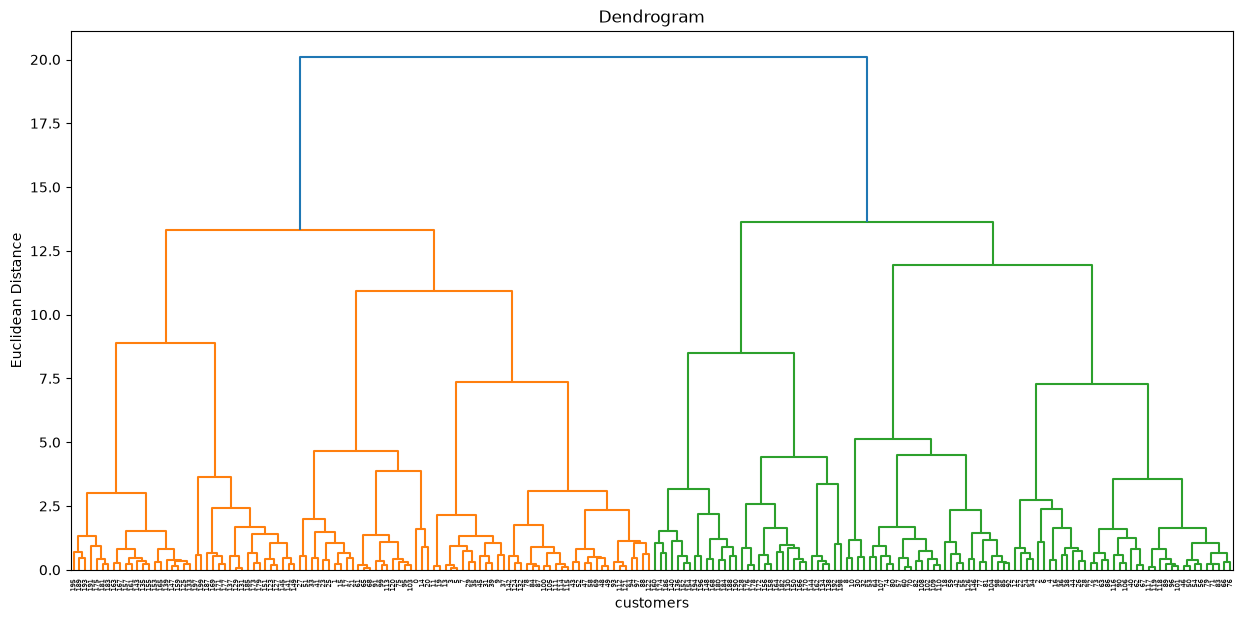

In [21]:
#Plot Dendrogram:-
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
plt.figure(figsize=(15,7))
dendrogram(linkage_matrix)
plt.title("Dendrogram")
plt.xlabel("customers")
plt.ylabel("Euclidean Distance")
plt.show()

## Dendrogram Interpretation

The dendrogram illustrates how customer clusters are merged based on Euclidean distance.

The largest vertical gap appears between approximately 13 and 20, suggesting that two clusters would be the mathematically optimal choice.

However, for customer segmentation, a lower cut around 7–8 produces five distinct clusters, allowing for more detailed business insights. Therefore, five clusters were selected for the Agglomerative Clustering model.

In [17]:
# creates a Hierarchical Clustering model:-
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(
    n_clusters=5,
    metric="euclidean",
    linkage="ward"
)
clusters=hc.fit_predict(x_scaled)
data["Cluster"]=clusters

# Cluster Visualization using PCA

## Objective

Principal Component Analysis (PCA) is used to reduce the high-dimensional dataset into two principal components.

This helps visualize the clusters formed by Hierarchical Clustering in a two-dimensional space.

PCA is used only for visualization and does not affect the clustering process.

In [18]:
#Apply PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)
x_pca=pd.DataFrame(
    x_pca,
    columns=["PC1","PC2"]
)
x_pca.head()

,PC1,PC2
0,-0.406383,-0.520714
1,-1.427673,-0.367310
2,0.050761,-1.894068
3,-1.694513,-1.631908
4,-0.313108,-1.810483


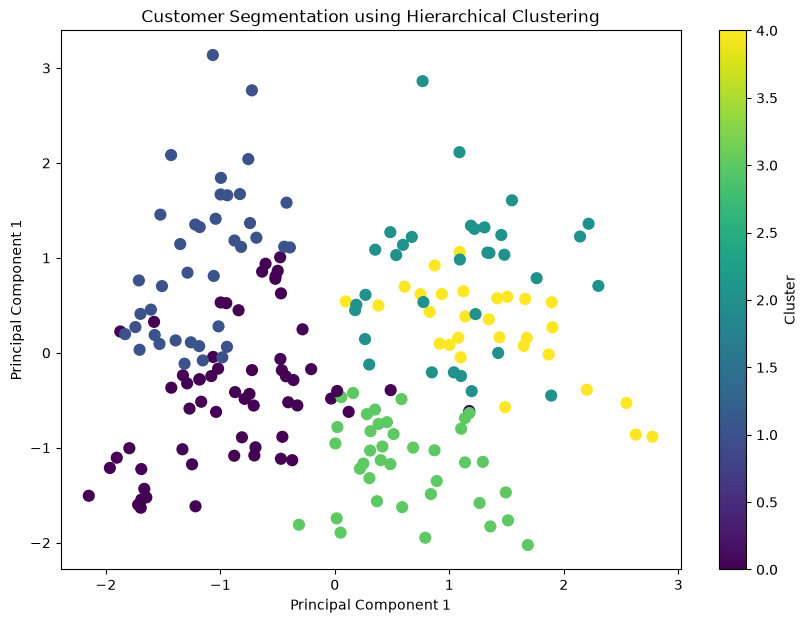

In [19]:
#Plot the Hierarchical Clusters:-
plt.figure(figsize=(10,7))
plt.scatter(
    x_pca["PC1"],
    x_pca["PC2"],
    c=data["Cluster"],
    cmap="viridis",
    s=60
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 1")
plt.title("Customer Segmentation using Hierarchical Clustering")
plt.colorbar(label="Cluster")
plt.show()

## Interpretation

The scatter plot represents customers in a two-dimensional space after applying PCA.

- Each point represents a customer.
- Different colors represent different clusters assigned by the Hierarchical Clustering algorithm.
- Customers within the same cluster share similar characteristics.
- Well-separated clusters indicate that the algorithm successfully grouped similar customers together.

PCA is used only to visualize the clusters and does not influence the clustering process.

## Cluster Visualization Interpretation

The scatter plot shows the customer segments obtained using Hierarchical Clustering after reducing the dataset to two principal components using PCA.

Observations:

- Five distinct customer groups are formed.
- Most clusters are reasonably well separated with only slight overlap.
- Customers within the same color share similar purchasing characteristics.
- The clustering algorithm successfully grouped customers with similar spending behavior and income levels.

PCA is used only for visualization purposes and does not influence the clustering algorithm.

In [20]:
#Cluster Profiling:-
cluster_details=data.groupby("Cluster").agg({
    "Age":"mean",
    "Annual Income (k$)":"mean",
    "Spending Score (1-100)":"mean"
})
cluster_details

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,26.147541,43.770492,58.967213
1,32.692308,86.538462,82.128205
2,41.454545,89.090909,16.181818
3,49.789474,44.105263,39.657895
4,56.551724,50.034483,41.344828


# Cluster Profiling

The average values of Age, Annual Income, and Spending Score were calculated for each cluster to understand customer characteristics.

## Cluster Summary

- Cluster 0: Young customers with moderate income and relatively high spending.
- Cluster 1: High-income, high-spending customers representing premium customers.
- Cluster 2: High-income customers with very low spending, representing potential customers for targeted marketing.
- Cluster 3: Older customers with moderate income and moderate spending.
- Cluster 4: Senior customers with moderate income and spending behavior.

# Project Conclusion

Hierarchical Clustering successfully segmented customers into five meaningful groups based on Age, Annual Income, and Spending Score.

The dendrogram was used to determine an appropriate number of clusters, while PCA enabled visualization of the customer segments in two dimensions.

The resulting clusters reveal different customer behaviors, allowing businesses to design targeted marketing campaigns, improve customer retention, and optimize promotional strategies.

Compared to K-Means, Hierarchical Clustering provides a hierarchical view of customer relationships through the dendrogram, making it easier to understand how clusters are formed.

# Skills Demonstrated

During this project, the following technical and analytical skills were applied:

- Python Programming
- Pandas
- NumPy
- Data Preprocessing
- Label Encoding
- Feature Scaling using StandardScaler
- Exploratory Data Analysis (EDA)
- Hierarchical Clustering (Agglomerative Clustering)
- Ward Linkage Method
- Euclidean Distance
- Dendrogram Analysis
- Principal Component Analysis (PCA)
- Cluster Visualization
- Customer Segmentation
- Cluster Profiling
- Business Insight Generation
- Data Visualization using Matplotlib and Seaborn

# Key Learnings

Through this project, I gained the following key learnings:

- Understood the concept of Unsupervised Machine Learning and customer segmentation.
- Learned how Hierarchical Clustering groups similar observations without predefined labels.
- Understood the difference between Agglomerative and Divisive Hierarchical Clustering.
- Learned the importance of feature scaling before applying distance-based algorithms.
- Understood how different linkage methods affect cluster formation, especially Ward Linkage.
- Learned how to interpret a Dendrogram and determine an appropriate number of clusters.
- Used PCA to visualize high-dimensional customer data in two dimensions.
- Created customer profiles by analyzing cluster characteristics.
- Generated business recommendations based on customer segments.
- Compared Hierarchical Clustering with K-Means Clustering and understood the strengths and limitations of both algorithms.